# Análisis de eficiencia de bits 21 metros de distancia
Este notebook analiza qué tan parecidos son los bits recibidos `bits_rx` con los bits transmitidos `bits_tx` y presenta gráficas, métricas de rendimiento y las imágenes que no cumplen con el criterio de coincidencia.

In [54]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image
import matplotlib.pyplot as plt

path = "./results/21m/"
nombre_csv = "resultados_comparacion_21m.csv"
df = pd.read_csv(path + nombre_csv)

# Vista rápida del DataFrame
display(df.head())
print(f"Filas totales: {len(df)}")


,num_auto,bw_plate_tx,bw_plate_rx,ocr_txt_tx,bits_equal,bit_errors,bits_tx,bits_rx
0,1,dataset_yolo/autos_bw/auto001.png,data_21m/autos_bw/auto001_rep01.png,KOZ.808,False,7,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]
1,1,dataset_yolo/autos_bw/auto001.png,data_21m/autos_bw/auto001_rep02.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]
2,1,dataset_yolo/autos_bw/auto001.png,data_21m/autos_bw/auto001_rep03.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]
3,1,dataset_yolo/autos_bw/auto001.png,data_21m/autos_bw/auto001_rep04.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]
4,1,dataset_yolo/autos_bw/auto001.png,data_21m/autos_bw/auto001_rep05.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]


Filas totales: 1349


## Distribución de errores de bit por imagen

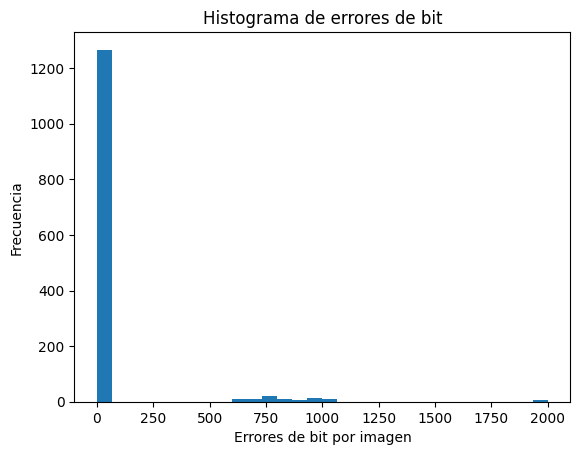

In [55]:
plt.figure()
df['bit_errors'].plot(kind='hist', bins=30)
plt.xlabel('Errores de bit por imagen')
plt.ylabel('Frecuencia')
plt.title('Histograma de errores de bit')
plt.show()


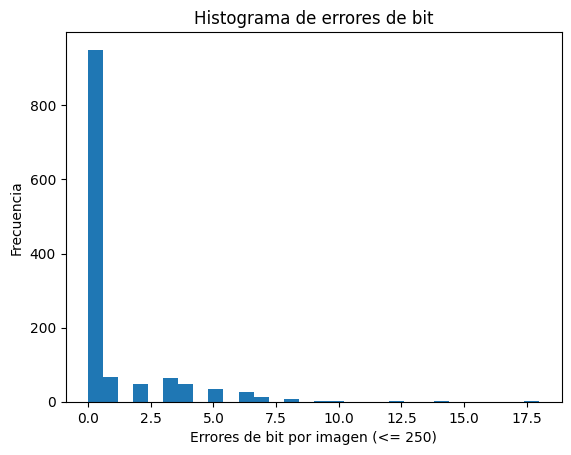

In [56]:
# Errores de bits por replica para cada auto con menos de 250 errores
test_df = df[df['bit_errors'] < 250]


plt.figure()
test_df['bit_errors'].plot(kind='hist', bins=30)
plt.xlabel('Errores de bit por imagen (<= 250)')
plt.ylabel('Frecuencia')
plt.title('Histograma de errores de bit')
plt.show()

## Errores de bit por réplica

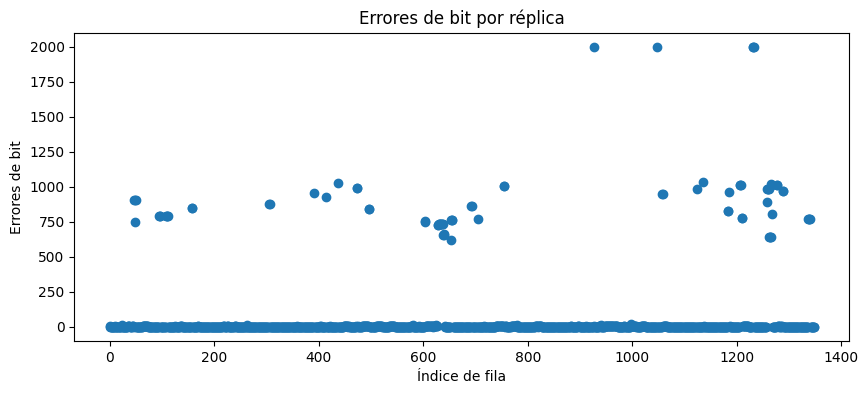

In [57]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['bit_errors'], marker='o', linestyle='none')
plt.xlabel('Índice de fila')
plt.ylabel('Errores de bit')
plt.title('Errores de bit por réplica')
plt.show()


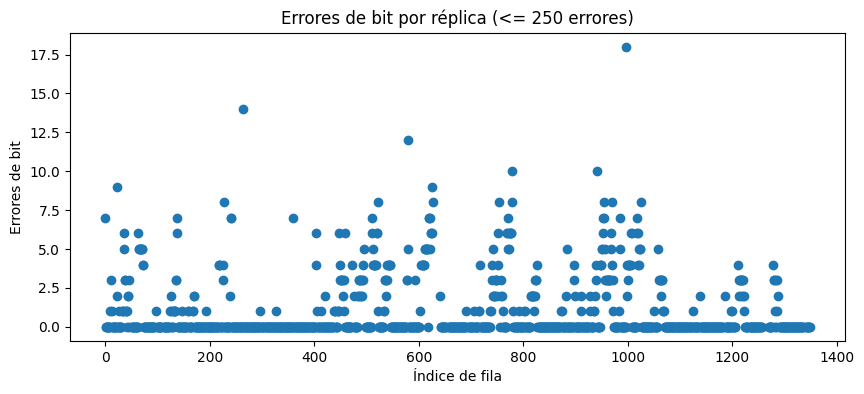

In [58]:
# Errores de bits por replica para cada auto con menos de 250 errores
test_df = df[df['bit_errors'] < 250]

plt.figure(figsize=(10,4))
plt.plot(test_df.index, test_df['bit_errors'], marker='o', linestyle='none')
plt.xlabel('Índice de fila')
plt.ylabel('Errores de bit')
plt.title('Errores de bit por réplica (<= 250 errores)')
plt.show()


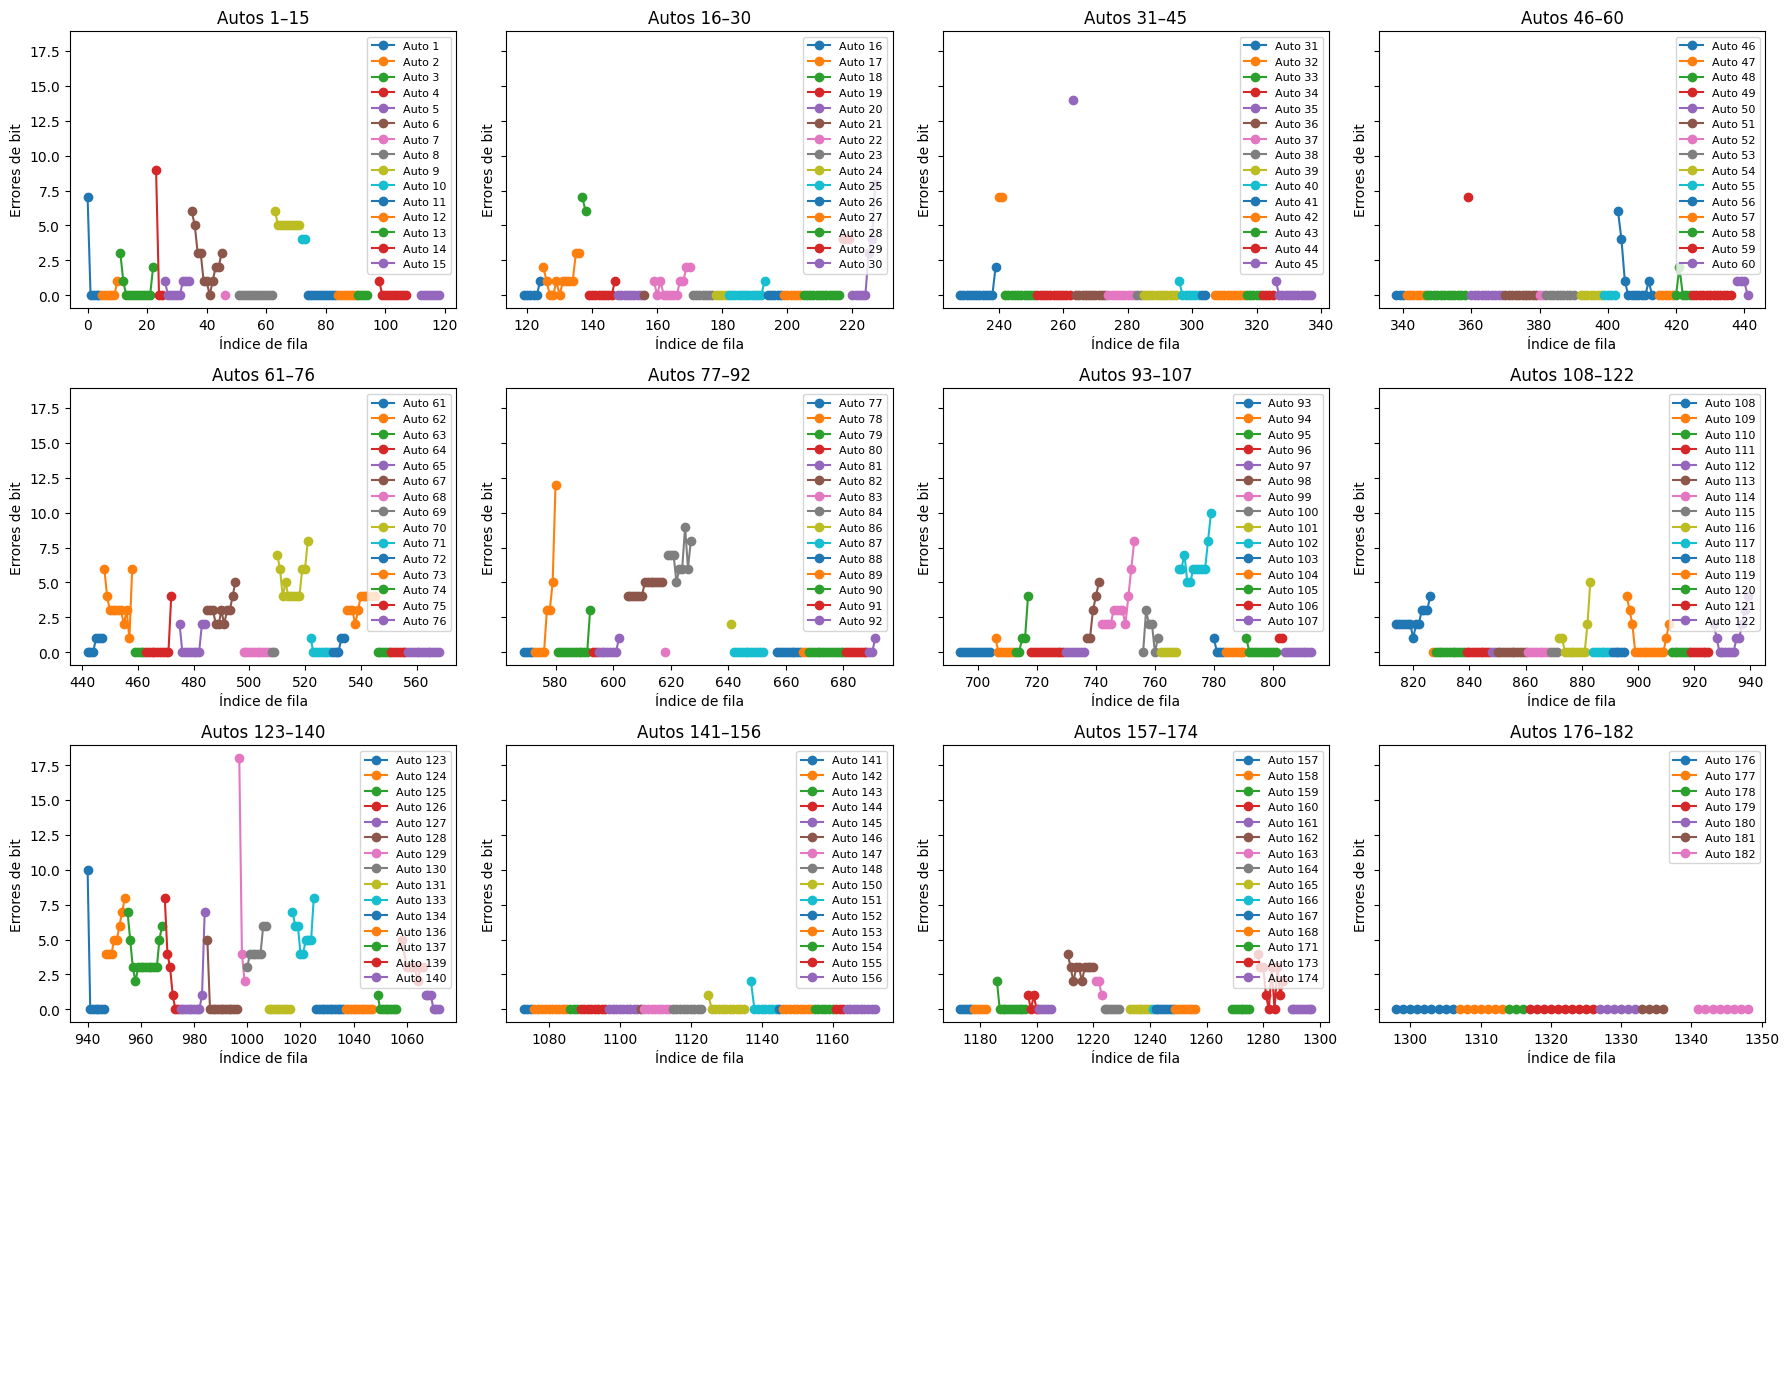

In [59]:
autos = sorted(test_df['num_auto'].unique())[:16*15]  # hasta 240 autos si hay suficientes
fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharey=True)
for idx, ax in enumerate(axes.flat):
    start = idx * 15
    end = start + 15
    if start >= len(autos):
        ax.axis('off')
        continue
    for i in autos[start:end]:
        auto_df = test_df[test_df['num_auto'] == i]
        ax.plot(auto_df.index, auto_df['bit_errors'], marker='o', linestyle='-', label=f'Auto {i}')
    ax.set_title(f'Autos {autos[start]}–{autos[min(end-1, len(autos)-1)]}')
    ax.set_xlabel('Índice de fila')
    ax.set_ylabel('Errores de bit')
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## Imágenes que no cumplen el criterio

In [60]:
# Eliminamos las que tienen 2000 errores, ya que es la imagen inversa
df = df[df['bit_errors'] < 2000]

In [61]:
import numpy as np   # por si no estaba importado

# --- Parámetros de tolerancia ---
BITS_TOTAL = 2000      
max_errors = 100  # máximo de bits erróneos permitidos
max_ber    = max_errors / BITS_TOTAL  # % BER máximo

# --- BER por fila ---
df['bits_total'] = BITS_TOTAL
df['ber'] = df['bit_errors'] / BITS_TOTAL

# --- Criterio de falla ---
fail_df = df[(df['bit_errors'] > max_errors) | (df['ber'] > max_ber)]

print(f'Imágenes que superan el umbral: {len(fail_df)}')
print(f'Total de imágenes: {len(df)}')
print(f'Porcentaje de fallos: {len(fail_df) / len(df) * 100:.2f}%')
display(
    fail_df[['num_auto', 'bw_plate_tx', 'bw_plate_rx',
             'bit_errors', 'ber']]
)


Imágenes que superan el umbral: 78
Total de imágenes: 1344
Porcentaje de fallos: 5.80%


,num_auto,bw_plate_tx,bw_plate_rx,bit_errors,ber
47,128,dataset_yolo/autos_bw/auto128.png,data_21m/autos_bw/auto128_rep01.png,904,0.4520
48,64,dataset_yolo/autos_bw/auto064.png,data_21m/autos_bw/auto064_rep01.png,750,0.3750
49,128,dataset_yolo/autos_bw/auto128.png,data_21m/autos_bw/auto128_rep02.png,904,0.4520
50,128,dataset_yolo/autos_bw/auto128.png,data_21m/autos_bw/auto128_rep03.png,903,0.4515
95,64,dataset_yolo/autos_bw/auto064.png,data_21m/autos_bw/auto064_rep02.png,793,0.3965
...,...,...,...,...,...
1289,46,dataset_yolo/autos_bw/auto046.png,data_21m/autos_bw/auto046_rep05.png,966,0.4830
1337,26,dataset_yolo/autos_bw/auto026.png,data_21m/autos_bw/auto026_rep06.png,773,0.3865
1338,26,dataset_yolo/autos_bw/auto026.png,data_21m/autos_bw/auto026_rep07.png,773,0.3865
1339,26,dataset_yolo/autos_bw/auto026.png,data_21m/autos_bw/auto026_rep08.png,773,0.3865


### Visualización de las primeras 5 imágenes fallidas

Auto 128 – errores: 904


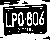

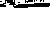

Auto 64 – errores: 750


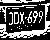

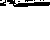

Auto 128 – errores: 904


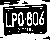

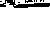

Auto 128 – errores: 903


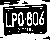

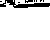

Auto 64 – errores: 793


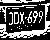

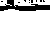

Auto 64 – errores: 793


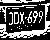

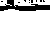

Auto 64 – errores: 792


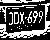

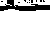

Auto 64 – errores: 791


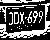

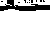

Auto 64 – errores: 791


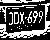

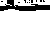

Auto 64 – errores: 790


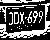

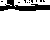

Auto 64 – errores: 789


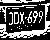

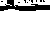

Auto 20 – errores: 846


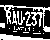

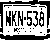

Auto 20 – errores: 847


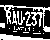

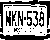

Auto 10 – errores: 877


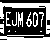

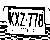

Auto 10 – errores: 877


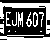

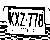

Auto 52 – errores: 958


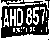

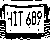

Auto 15 – errores: 927


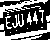

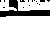

Auto 89 – errores: 1030


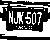

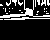

Auto 16 – errores: 988


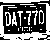

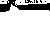

Auto 16 – errores: 988


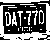

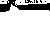

Auto 2 – errores: 839


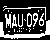

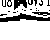

Auto 2 – errores: 839


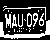

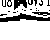

Auto 65 – errores: 753


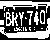

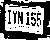

Auto 65 – errores: 748


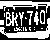

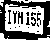

Auto 80 – errores: 725


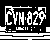

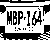

In [62]:
path = 'results/21m/'

for _, row in fail_df.head(25).iterrows():
    print(f"Auto {row['num_auto']} – errores: {row['bit_errors']}")
    display(Image(filename=row['bw_plate_tx']))
    display(Image(filename=path + row['bw_plate_rx']))


In [63]:
# --- Umbral de bits erróneos ---
thr_err = 15

# --- Agrupar por auto y comprobar si alguna réplica cumple ---
auto_status = (
    df.groupby('num_auto')['bit_errors']
      .apply(lambda s: (s < thr_err).any())   # True = tiene al menos una buena
)

# Autos sin réplica “buena”
failed_autos = auto_status[~auto_status]      # False significa que falló
num_failed   = failed_autos.size
num_total    = auto_status.size

print(f'Autos sin ninguna réplica con < {thr_err} errores de bit: '
      f'{num_failed} de {num_total}')

# Mostrar la lista (si quieres verla)
display(failed_autos.index.tolist())


Autos sin ninguna réplica con < 15 errores de bit: 2 de 174


[138, 175]